# Gas Consumption Forecasting
#### Anomaly Detection in Time Series - Jacek Młynarczyk

### Preprocessing and Exploratory Data Analysis

The data that we will be analyzing depicts the monthly cost of gas consumption for a single-family house. After initial analysis I have concluded, that the values were supposed to be chronological, but a few typos occured. We will need to fix them before going forward. There are also three different date formats used, which also needs to be standardized.

In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Extraction
df = pd.read_csv('cost.csv', sep='\t')

# Fixing the typos identified in the preliminary analysis so the timeline is continuous.
df.loc[df['invoice issue date'] == '11.2010', 'invoice issue date'] = '11.2019'
df.loc[df['invoice issue date'] == '5.2019', 'invoice issue date'] = '5.2020'
df.loc[df['invoice issue date'] == '11.2020', 'invoice issue date'] = '11.2021'
df.loc[df['invoice issue date'] == '1/2022', 'invoice issue date'] = '1/2023'
df.loc[df['invoice issue date'] == '8/2025', 'invoice issue date'] = '8/2023'

# Function to parse the various date formats found in the file
def clean_date_format(date_str):
    try:
        # Try converting 'MM.YYYY'
        return pd.to_datetime(date_str, format='%m.%Y')
    except ValueError:
        try:
            # Try converting 'YYYY-MM-DD'
            return pd.to_datetime(date_str)
        except ValueError:
            try:
                # Try converting 'M/YYYY'
                return pd.to_datetime(date_str, format='%m/%Y')
            except ValueError:
                # Return None if else
                return pd.NaT

df['invoice issue date'] = df['invoice issue date'].apply(clean_date_format)
df['invoice issue date'] = df['invoice issue date'].dt.to_period('M').dt.to_timestamp()
# df['invoice issue date'] = df['invoice issue date'].dt.strftime('%m.%Y')

# print(df)

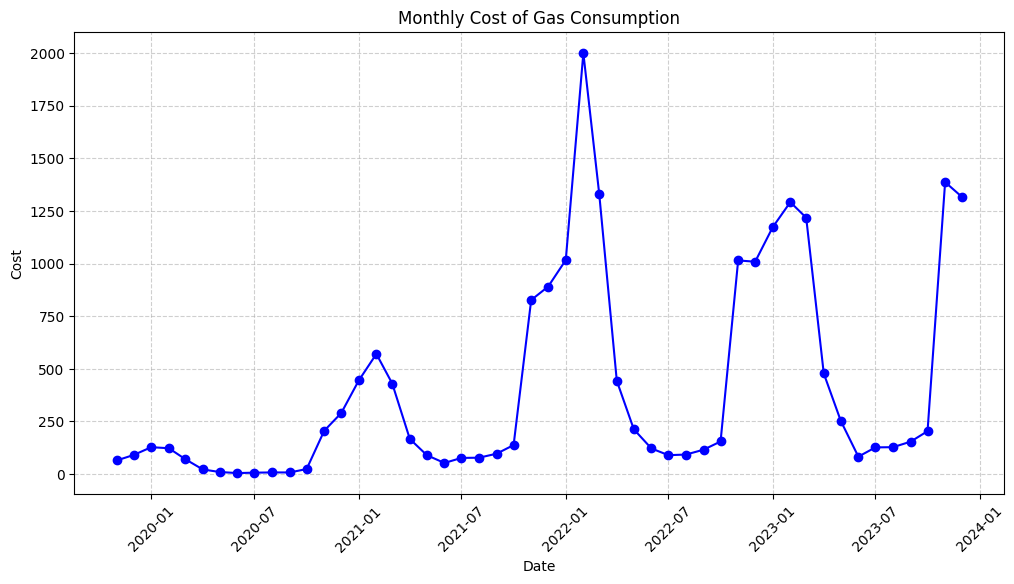

In [213]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df['invoice issue date'], df['cost of heating'], marker='o', linestyle='-', color='b')

# Formatting
plt.title('Monthly Cost of Gas Consumption')
plt.xlabel('Date')
plt.ylabel('Cost')
plt.grid(True, linestyle='--', alpha=0.6)

# plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

The data is highly seasonal, as the cost is higher during the winter. The series is likely to be multiplicative, as the magnitude and variance increase over time. We can easily see, that the value in 2022-02 is very likely to be an anomaly. This may be explained by the fact, that this was the month of Russian invasion on Ukraine. Since Russia was a major gas supplier in Europe, this could have affected the gas prices from then on.

#### Anomaly Detection
Before we can forecast future values with a model, we need to remove the anomaly, as it should not be taken into account for the future predictions.

   invoice issue date  cost of heating   z_score
27         2022-02-01             2000  3.230794


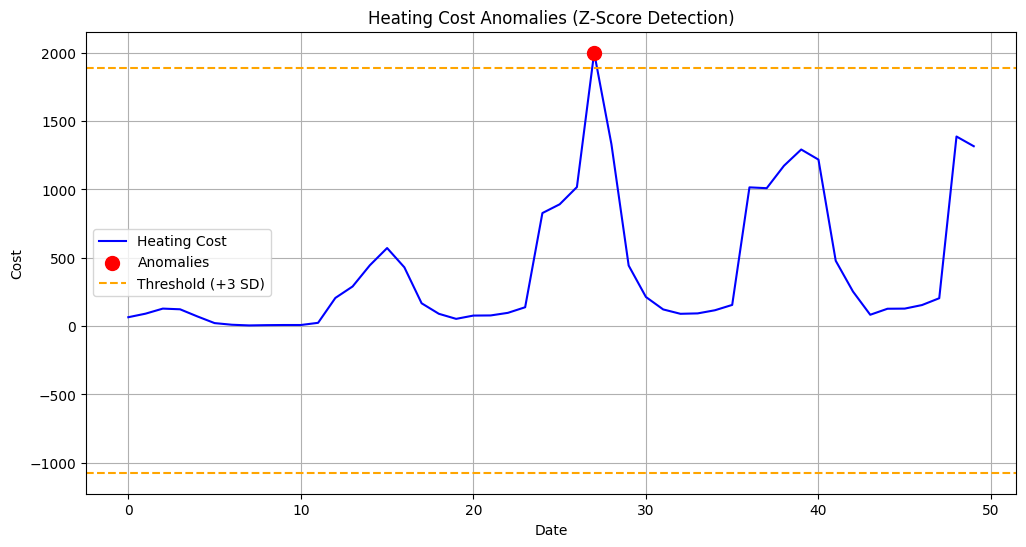

In [214]:
mean_cost = df['cost of heating'].mean()
std_cost = df['cost of heating'].std()

df['z_score'] = (df['cost of heating'] - mean_cost) / std_cost

threshold = 3
anomalies = df[np.abs(df['z_score']) > threshold]
print(anomalies)

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['cost of heating'], label='Heating Cost', color='blue')
plt.scatter(anomalies.index, anomalies['cost of heating'], color='red', label='Anomalies', s=100, zorder=5)

plt.axhline(mean_cost + threshold * std_cost, color='orange', linestyle='--', label=f'Threshold (+{threshold} SD)')
plt.axhline(mean_cost - threshold * std_cost, color='orange', linestyle='--')

plt.title('Heating Cost Anomalies (Z-Score Detection)')
plt.xlabel('Date')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()

In [215]:
# Fixing the Anomaly
anomalies_mask = np.abs(df['z_score']) > 3
anomalies = df[anomalies_mask]

df_corrected = df.copy()

# Set the anomalies to NaN
df_corrected.loc[anomalies.index, 'cost of heating'] = np.nan

# Interpolate to fill the NaNs
df_corrected['cost of heating'] = df_corrected['cost of heating'].interpolate(method='linear')
df_corrected['cost of heating'] = df_corrected['cost of heating'].round().astype(int)

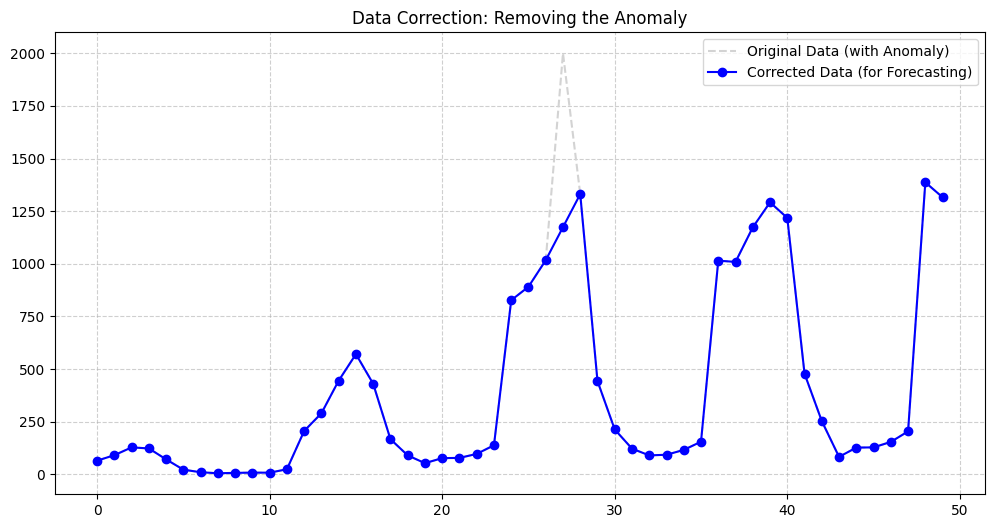

In [216]:
# Compare Original vs Corrected
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['cost of heating'], label='Original Data (with Anomaly)', color='lightgray', linestyle='--')
plt.plot(df_corrected.index, df_corrected['cost of heating'], label='Corrected Data (for Forecasting)', color='blue', marker='o')
plt.title('Data Correction: Removing the Anomaly')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### SARIMA Forecast

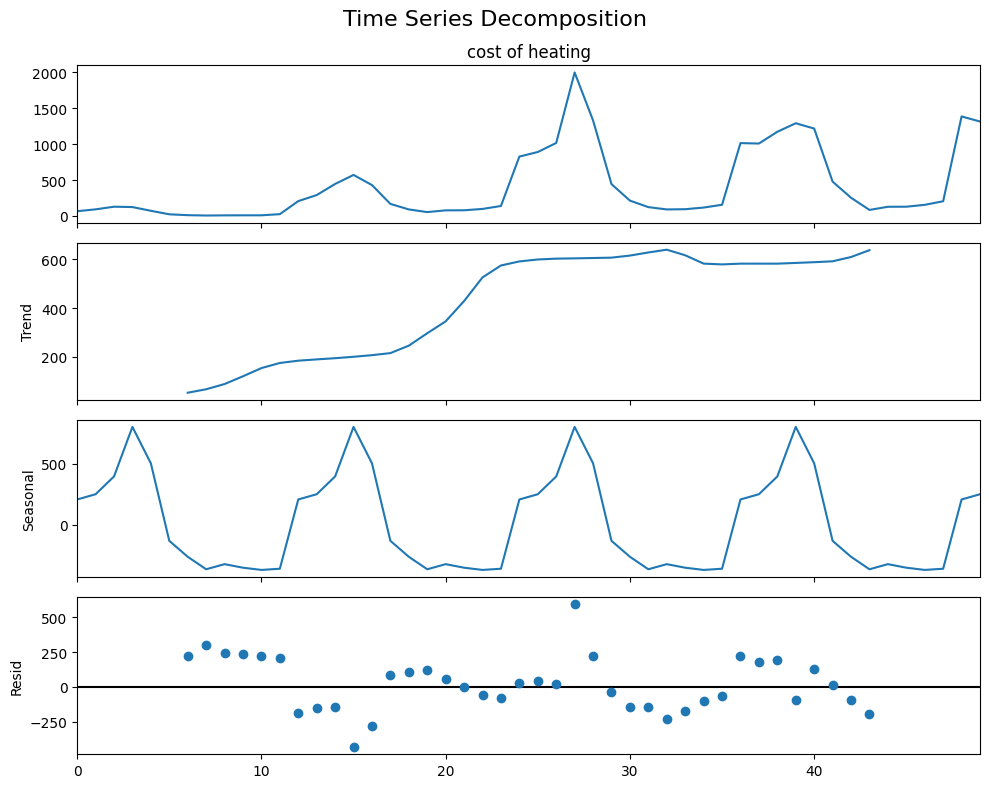

In [222]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['cost of heating'], model='additive', period=12)
# result = seasonal_decompose(df['cost of heating'], model='multiplicative', period=12)

# Plot decomposition
plt.rcParams.update({'figure.figsize': (10, 8)})
result.plot()
plt.suptitle('Time Series Decomposition', fontsize=16)
plt.tight_layout()
plt.show()

In [218]:
import pmdarima as pm

df_corrected.set_index('invoice issue date', inplace=True)
df_corrected.index.freq = 'MS'

print("Searching for best model parameters...")

# Auto-ARIMA finds the best parameters
model = pm.auto_arima(df_corrected['cost of heating'],
                      seasonal=True, m=12,
                      start_p=0, start_q=0, max_order=5,
                      test='adf',       # use adftest to find optimal 'd'
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True,
                      trace=True) # prints the search progress

print("\nBest Model Found:")
print(model.summary())

Searching for best model parameters...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(1,1,1)[12]             : AIC=inf, Time=0.20 sec
 ARIMA(0,2,0)(0,1,0)[12]             : AIC=503.423, Time=0.02 sec
 ARIMA(1,2,0)(1,1,0)[12]             : AIC=496.540, Time=0.09 sec
 ARIMA(0,2,1)(0,1,1)[12]             : AIC=inf, Time=0.12 sec
 ARIMA(1,2,0)(0,1,0)[12]             : AIC=494.578, Time=0.04 sec
 ARIMA(1,2,0)(0,1,1)[12]             : AIC=496.548, Time=0.11 sec
 ARIMA(1,2,0)(1,1,1)[12]             : AIC=inf, Time=0.40 sec
 ARIMA(2,2,0)(0,1,0)[12]             : AIC=490.200, Time=0.05 sec
 ARIMA(2,2,0)(1,1,0)[12]             : AIC=491.481, Time=0.13 sec
 ARIMA(2,2,0)(0,1,1)[12]             : AIC=491.642, Time=0.14 sec
 ARIMA(2,2,0)(1,1,1)[12]             : AIC=inf, Time=0.47 sec
 ARIMA(3,2,0)(0,1,0)[12]             : AIC=488.580, Time=0.07 sec
 ARIMA(3,2,0)(1,1,0)[12]             : AIC=489.401, Time=0.18 sec
 ARIMA(3,2,0)(0,1,1)[12]             : AIC=489.680, Time=0.17 sec
 ARIMA(3,2

Even though Auto-ARIMA decided that the best model is ARIMA(3,2,0)(0,1,0), we will be using ARIMA(3,0,0)(0,1,0), as differencing makes the prediction worse.

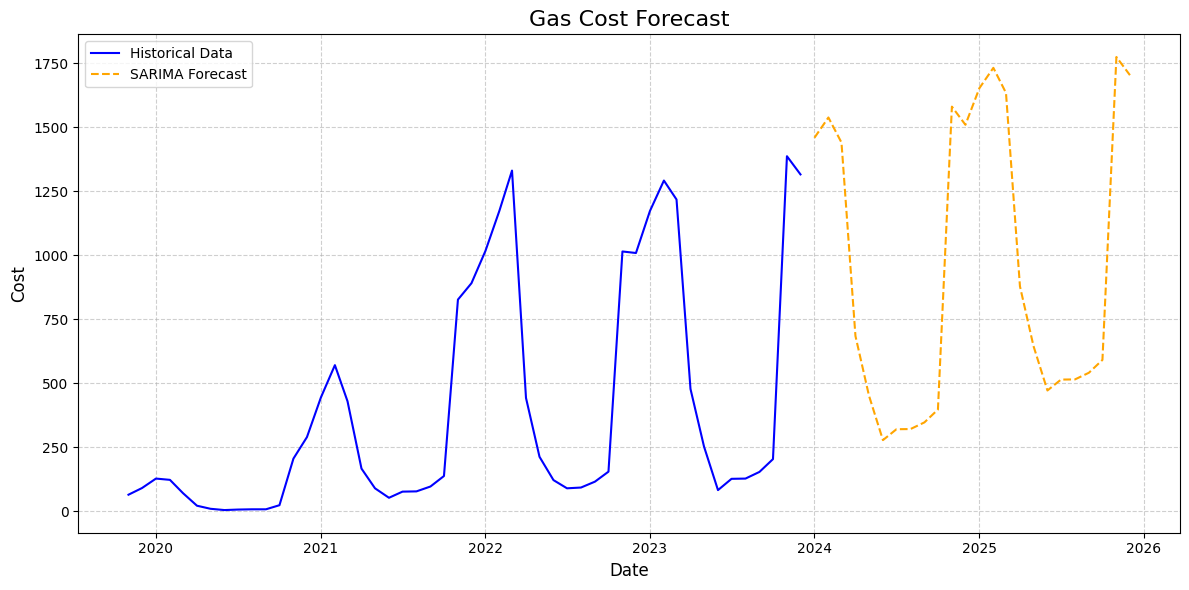

In [230]:
model = pm.ARIMA(order=(3, 0, 0), seasonal_order=(0, 1, 0, 12))
model.fit(df_corrected['cost of heating'])

n_periods = 24  # Forecast 2 years into the future
fitted, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)

future_dates = pd.date_range(df_corrected.index[-1], periods=n_periods + 1, freq='MS')[1:]

forecast_series = pd.Series(fitted, index=future_dates)
lower_series = pd.Series(conf_int[:, 0], index=future_dates)
upper_series = pd.Series(conf_int[:, 1], index=future_dates)

plt.figure(figsize=(12, 6))
plt.plot(df_corrected.index, df_corrected['cost of heating'], label='Historical Data', color='blue')
plt.plot(forecast_series.index, forecast_series, label='SARIMA Forecast', color='orange', linestyle='--')

plt.title('Gas Cost Forecast', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Results
In the end, after removing the anomaly, we were able to propose a model that forecasts future behavior. I have encountered multiple problems, starting with cleaning the data, where the different date formats took sometime to be standardized. Then with seasonal decomposition, even though it looks like a multiplicative series, decomposition looks betterwhen additive model is used. Lastly, finding right parameters for SARIMA model also proved to be difficult, as the auto-ARIMA found the model, that didn't predict the future as well as the model I used in the end.